In [1]:
!git clone https://github.com/Deeptixx/ceam_task_1.git

Cloning into 'ceam_task_1'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 148 (delta 4), reused 144 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 2.39 MiB | 14.91 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
%cd ceam_task_1

/kaggle/working/ceam_task_1


In [3]:
import os
import numpy as np
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-06-11 19:10:00.181003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781205000.411884      97 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781205000.478663      97 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781205001.040060      97 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781205001.040115      97 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781205001.040118      97 computation_placer.cc:177] computation placer alr

In [4]:
!ls /kaggle/working/ceam_task_1/dataset

book  calculator  clock  headphones  phone


In [5]:
data_dir = '/kaggle/working/ceam_task_1/dataset'
classes = ['phone', 'book', 'headphones', 'calculator', 'clock']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
image_paths = []
labels = []
for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_idx[class_name])
print(f"Total images: {len(image_paths)}")
print(f"Class distribution: {np.bincount(labels)}")

Total images: 125
Class distribution: [25 25 25 25 25]


In [6]:
images = []
for img_path in image_paths:
    img = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img)
    images.append(img_array)
images = np.array(images)
labels = np.array(labels)
print(f"Images shape: {images.shape}")  #(125,224,224,3)
print(f"Labels shape: {labels.shape}")  #(125,)
images = images / 255.0 #normalizing pixel values

Images shape: (125, 224, 224, 3)
Labels shape: (125,)


In [7]:
# 70% train 15% val 15% test
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, random_state=SEED, stratify=labels
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"\nTrain class distribution: {np.bincount(train_labels)}")
print(f"Val class distribution: {np.bincount(val_labels)}")
print(f"Test class distribution: {np.bincount(test_labels)}")

Train: 87, Val: 19, Test: 19

Train class distribution: [17 18 17 17 18]
Val class distribution: [4 3 4 4 4]
Test class distribution: [4 4 4 4 3]


In [8]:
def create_baseline_model(dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', 
                      input_shape=(224, 224, 3)),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(5, activation='softmax')
    ])
    
    return model
model = create_baseline_model(dropout_rate=0.5)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781205018.796397      97 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781205018.799327      97 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
learning_rate = 0.001
batch_size = 8
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy', #integer labels(0,1,2,3,4)
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_images, train_labels,
    batch_size=batch_size,  
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=1
)

Epoch 1/50


I0000 00:00:1781205022.097621     151 service.cc:152] XLA service 0x79f9042489b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781205022.097657     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781205022.097661     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781205022.498104     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2611 - loss: 1.6011

I0000 00:00:1781205026.161999     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-06-11 19:10:27.391073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 19:10:27.534167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 507ms/step - accuracy: 0.2299 - loss: 1.6185 - val_accuracy: 0.2105 - val_loss: 1.5977
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2184 - loss: 1.5857 - val_accuracy: 0.2105 - val_loss: 1.5888
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2989 - loss: 1.5741 - val_accuracy: 0.2105 - val_loss: 1.5683
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2184 - loss: 1.5622 - val_accuracy: 0.2105 - val_loss: 1.5414
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2299 - loss: 1.5219 - val_accuracy: 0.2105 - val_loss: 1.5029
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1954 - loss: 1.5083 - val_accuracy: 0.3158 - val_loss: 1.4761
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3333 - loss: 1.4705 - val_accuracy: 0.5263 - val_loss: 1.4519
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3793 - loss: 1.4409 - val_accuracy: 0.4737 - val_loss: 

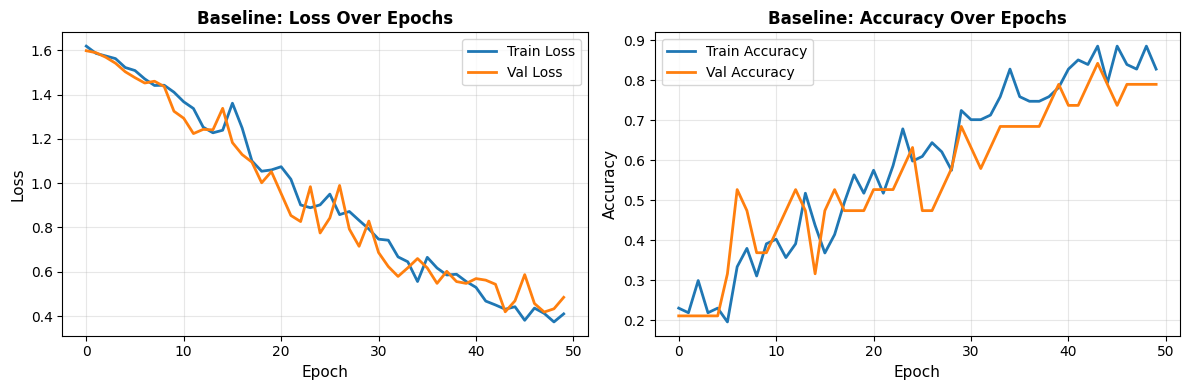

Baseline Summary:
Final Train Accuracy: 82.76%
Final Val Accuracy: 78.95%
Overfitting Gap: 3.81%


In [11]:
#extracting metrics from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_loss, label='Train Loss', linewidth=2)
axes[0].plot(val_loss, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Baseline: Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3) #LOSS PLOT

axes[1].plot(train_acc, label='Train Accuracy', linewidth=2)
axes[1].plot(val_acc, label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Baseline: Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3) #ACCURACY PLOT

plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Baseline Summary:")
print(f"Final Train Accuracy: {train_acc[-1]*100:.2f}%")
print(f"Final Val Accuracy: {val_acc[-1]*100:.2f}%")
print(f"Overfitting Gap: {(train_acc[-1] - val_acc[-1])*100:.2f}%")

In [12]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)
class_names = ['phone', 'calculator', 'book', 'clock', 'headphones']
for class_idx, class_name in enumerate(class_names):
    class_mask = test_labels == class_idx
    if class_mask.sum() > 0:
        class_acc = (predicted_labels[class_mask] == class_idx).sum() / class_mask.sum()
        print(f"{class_name}: {class_acc*100:.2f}%")

Test Accuracy: 78.95%
Test Loss: 0.5084
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step
phone: 75.00%
calculator: 100.00%
book: 25.00%
clock: 100.00%
headphones: 100.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


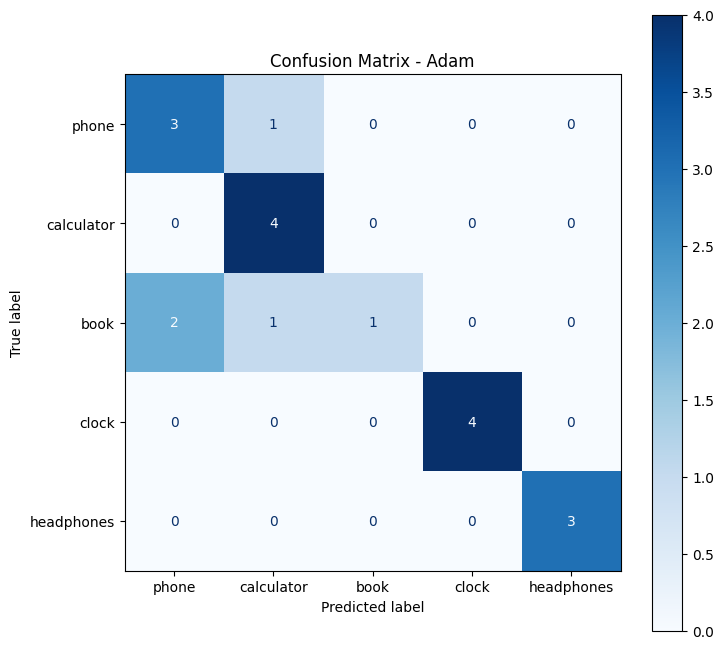

In [13]:
# confusion matrix for best performing optimizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(test_images)
y_pred = y_pred.argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['phone', 'calculator', 'book', 'clock', 'headphones']
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Adam')
plt.show()

In [14]:
model.save("/kaggle/working/baseline.keras")

In [15]:
!ls -lh /kaggle/working

total 1.4M
-rw-r--r-- 1 root root 1.4M Jun 11 19:10 baseline.keras
drwxr-xr-x 5 root root 4.0K Jun 11 19:10 ceam_task_1
